# 06.1 — Metric Illustrations & Full-Context UMAP

**Purpose:** Two complementary visualizations for the CD8+ holdout experiment:
1. **R² toy examples** — step-by-step illustrations of how `r2_means` and `r2_stds` are computed
2. **Full-context UMAP** — all ~12,800 cells as a stable gray reference map with CD8+ populations highlighted

**Why full-context UMAP?** Notebook 06's UMAPs show CD8+ cells in isolation.
Without surrounding cell types, we cannot tell whether predictions land in the
correct CD8+ neighborhood or drift toward other cell-type identities.

In [1]:
import sys
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import anndata
import scanpy as sc
from pathlib import Path
from scipy import sparse

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

RESULTS = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8")
IMPACT_OR_DIR = RESULTS / "impact_or"
CELLOT_DIR    = RESULTS / "cellot"
SCGEN_DIR     = RESULTS / "speciesot_scgen"

DATA_PATH = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse/cd8_holdout_v07.h5ad")

HOLDOUT  = "CL:0000625"
CT_COL   = "cell_type_ontology_term_id"
SOURCE, TARGET = "mouse", "human"

def to_dense(X):
    if sparse.issparse(X):
        return np.array(X.todense())
    return np.array(X)

print("Setup complete.")

Setup complete.


---
## Part 1 — R² Metrics: Toy Example Walkthrough

The two core R² metrics used in our OOD evaluation:
- **R² of means** (`r2_means`): How well do per-gene *average* expression levels in predicted cells match actual cells?
- **R² of stds** (`r2_stds`): How well do per-gene *standard deviations* in predicted cells match actual cells?

Both are standard coefficient-of-determination (R²) values computed in **gene space** — each gene contributes one point to the scatter plot.

In [2]:
np.random.seed(42)

genes = ['IFNG', 'CD8A', 'GZMB', 'PRF1', 'TNF']
n_genes = len(genes)

actual_expr = np.array([
    [3.2, 5.1, 2.8, 1.5, 2.0],
    [2.8, 4.7, 3.1, 1.8, 1.7],
    [3.5, 5.3, 2.5, 1.2, 2.3],
    [3.0, 4.9, 2.9, 1.6, 1.9],
    [2.9, 5.0, 3.0, 1.4, 2.1],
    [3.1, 4.8, 2.7, 1.7, 1.8],
])

pred_expr = np.array([
    [2.9, 4.8, 2.5, 1.6, 2.2],
    [2.6, 4.5, 2.8, 1.9, 1.8],
    [3.2, 5.0, 2.3, 1.3, 2.5],
    [2.7, 4.6, 2.6, 1.5, 2.0],
    [2.8, 4.7, 2.7, 1.5, 2.1],
    [3.0, 4.9, 2.4, 1.8, 1.9],
])

actual_means = actual_expr.mean(axis=0)
pred_means   = pred_expr.mean(axis=0)

SS_res = np.sum((actual_means - pred_means) ** 2)
SS_tot = np.sum((actual_means - actual_means.mean()) ** 2)
r2_means = 1 - SS_res / SS_tot

print("=" * 60)
print("R\u00b2 of Means \u2014 Step-by-step computation")
print("=" * 60)
print(f"\n6 cells \u00d7 5 genes  (toy data)")
print(f"\nActual expression matrix (6 cells \u00d7 5 genes):")
print(pd.DataFrame(actual_expr, columns=genes,
                   index=[f'cell_{i}' for i in range(6)]).to_string())

print(f"\nPredicted expression matrix:")
print(pd.DataFrame(pred_expr, columns=genes,
                   index=[f'cell_{i}' for i in range(6)]).to_string())

print(f"\n{'Gene':<8} {'Actual \u03bc':>10} {'Pred \u03bc':>10} {'Residual':>10} {'Residual\u00b2':>12}")
print("-" * 54)
for i, g in enumerate(genes):
    r = actual_means[i] - pred_means[i]
    print(f"{g:<8} {actual_means[i]:>10.4f} {pred_means[i]:>10.4f} {r:>10.4f} {r**2:>12.6f}")

y_bar = actual_means.mean()
print(f"\nOverall mean of actual means (\u0233) = {y_bar:.4f}")
print(f"SS_res = \u03a3(actual\u03bc_g \u2212 pred\u03bc_g)\u00b2 = {SS_res:.6f}")
print(f"SS_tot = \u03a3(actual\u03bc_g \u2212 \u0233)\u00b2         = {SS_tot:.6f}")
print(f"\nR\u00b2_means = 1 \u2212 SS_res/SS_tot = 1 \u2212 {SS_res:.6f}/{SS_tot:.6f} = {r2_means:.4f}")

R² of Means — Step-by-step computation

6 cells × 5 genes  (toy data)

Actual expression matrix (6 cells × 5 genes):
        IFNG  CD8A  GZMB  PRF1  TNF
cell_0   3.2   5.1   2.8   1.5  2.0
cell_1   2.8   4.7   3.1   1.8  1.7
cell_2   3.5   5.3   2.5   1.2  2.3
cell_3   3.0   4.9   2.9   1.6  1.9
cell_4   2.9   5.0   3.0   1.4  2.1
cell_5   3.1   4.8   2.7   1.7  1.8

Predicted expression matrix:
        IFNG  CD8A  GZMB  PRF1  TNF
cell_0   2.9   4.8   2.5   1.6  2.2
cell_1   2.6   4.5   2.8   1.9  1.8
cell_2   3.2   5.0   2.3   1.3  2.5
cell_3   2.7   4.6   2.6   1.5  2.0
cell_4   2.8   4.7   2.7   1.5  2.1
cell_5   3.0   4.9   2.4   1.8  1.9

Gene       Actual μ     Pred μ   Residual    Residual²
------------------------------------------------------
IFNG         3.0833     2.8667     0.2167     0.046944
CD8A         4.9667     4.7500     0.2167     0.046944
GZMB         2.8333     2.5500     0.2833     0.080278
PRF1         1.5333     1.6000    -0.0667     0.004444
TNF          1.966

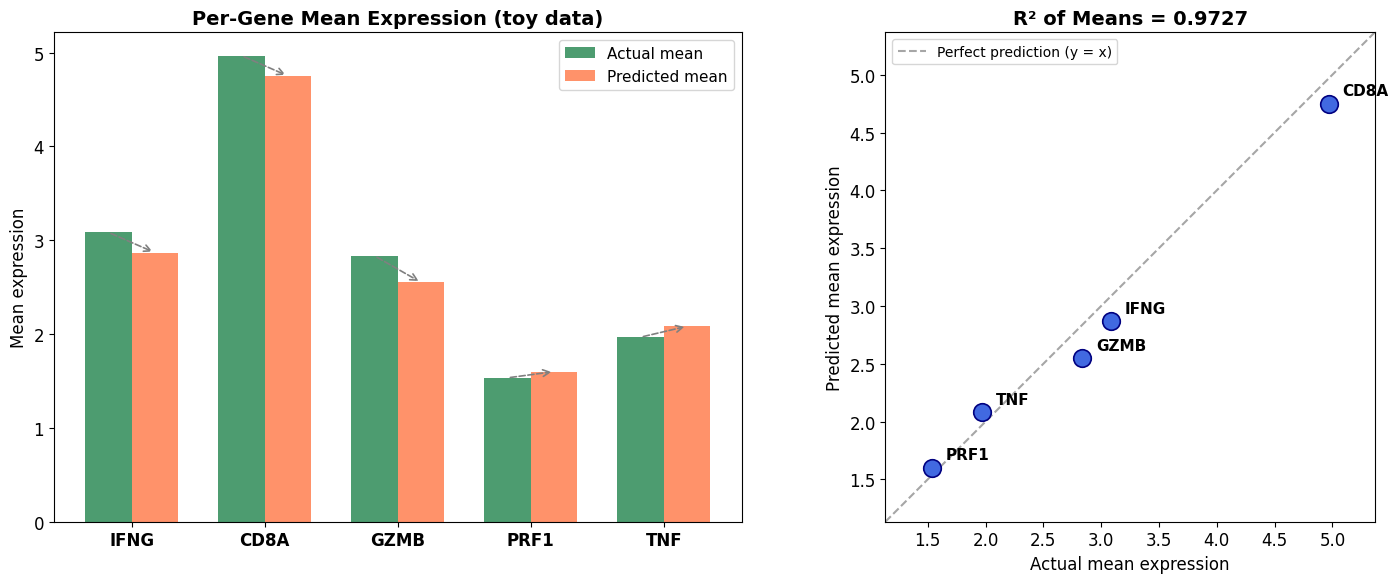

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: grouped bar chart
ax = axes[0]
x = np.arange(n_genes)
w = 0.35
bars_a = ax.bar(x - w/2, actual_means, w, color='seagreen', alpha=0.85, label='Actual mean')
bars_p = ax.bar(x + w/2, pred_means, w, color='coral', alpha=0.85, label='Predicted mean')
ax.set_xticks(x)
ax.set_xticklabels(genes, fontsize=12, fontweight='bold')
ax.set_ylabel('Mean expression', fontsize=12)
ax.set_title('Per-Gene Mean Expression (toy data)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
for i in range(n_genes):
    ax.annotate('', xy=(x[i] + w/2, pred_means[i]),
                xytext=(x[i] - w/2, actual_means[i]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2, ls='--'))

# Right: R² scatter plot
ax = axes[1]
pad = 0.4
lo = min(actual_means.min(), pred_means.min()) - pad
hi = max(actual_means.max(), pred_means.max()) + pad
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.35, lw=1.5, label='Perfect prediction (y = x)')
ax.scatter(actual_means, pred_means, s=160, c='royalblue', edgecolors='navy',
           linewidths=1.2, zorder=5)
for i, g in enumerate(genes):
    ax.annotate(g, (actual_means[i], pred_means[i]),
                textcoords="offset points", xytext=(10, 6),
                fontsize=11, fontweight='bold')
ax.set_xlabel('Actual mean expression', fontsize=12)
ax.set_ylabel('Predicted mean expression', fontsize=12)
ax.set_title(f'R\u00b2 of Means = {r2_means:.4f}', fontsize=14, fontweight='bold')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

### R² of Standard Deviations

Same concept, but comparing per-gene **standard deviations** instead of means.
This captures whether the model reproduces the *spread* of expression across cells, not just the average level.

R² of Stds — Step-by-step computation

Gene       Actual σ     Pred σ    Residual²
--------------------------------------------
IFNG         0.2483     0.2160     0.001043
CD8A         0.2160     0.1871     0.000838
GZMB         0.2160     0.1871     0.000838
PRF1         0.2160     0.2191     0.000009
TNF          0.2160     0.2483     0.001043

Overall mean of actual stds (ȳ) = 0.2225
SS_res = 0.003772
SS_tot = 0.000835
R²_stds = 1 − 0.003772/0.000835 = -3.5181


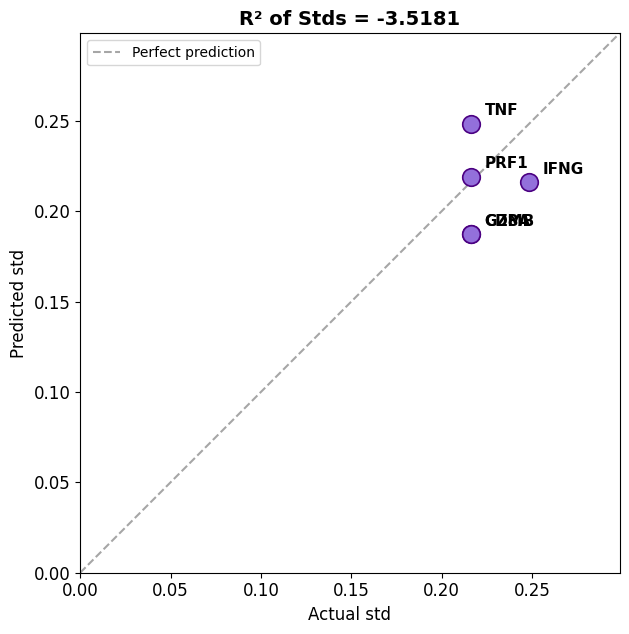

In [4]:
actual_stds = actual_expr.std(axis=0, ddof=1)
pred_stds   = pred_expr.std(axis=0, ddof=1)

SS_res_s = np.sum((actual_stds - pred_stds) ** 2)
SS_tot_s = np.sum((actual_stds - actual_stds.mean()) ** 2)
r2_stds = 1 - SS_res_s / SS_tot_s

print("=" * 60)
print("R\u00b2 of Stds \u2014 Step-by-step computation")
print("=" * 60)
print(f"\n{'Gene':<8} {'Actual \u03c3':>10} {'Pred \u03c3':>10} {'Residual\u00b2':>12}")
print("-" * 44)
for i, g in enumerate(genes):
    r = actual_stds[i] - pred_stds[i]
    print(f"{g:<8} {actual_stds[i]:>10.4f} {pred_stds[i]:>10.4f} {r**2:>12.6f}")

s_bar = actual_stds.mean()
print(f"\nOverall mean of actual stds (\u0233) = {s_bar:.4f}")
print(f"SS_res = {SS_res_s:.6f}")
print(f"SS_tot = {SS_tot_s:.6f}")
print(f"R\u00b2_stds = 1 \u2212 {SS_res_s:.6f}/{SS_tot_s:.6f} = {r2_stds:.4f}")

fig, ax = plt.subplots(figsize=(7, 6.5))
pad = 0.05
lo = 0
hi = max(actual_stds.max(), pred_stds.max()) + pad
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.35, lw=1.5, label='Perfect prediction')
ax.scatter(actual_stds, pred_stds, s=160, c='mediumpurple', edgecolors='indigo',
           linewidths=1.2, zorder=5)
for i, g in enumerate(genes):
    ax.annotate(g, (actual_stds[i], pred_stds[i]),
                textcoords="offset points", xytext=(10, 6),
                fontsize=11, fontweight='bold')
ax.set_xlabel('Actual std', fontsize=12)
ax.set_ylabel('Predicted std', fontsize=12)
ax.set_title(f'R\u00b2 of Stds = {r2_stds:.4f}', fontsize=14, fontweight='bold')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

### Key Takeaway

| Metric | What it measures | Perfect | Bad |
|--------|-----------------|---------|-----|
| `r2_means` | Gene-level mean accuracy | 1.0 | ≤ 0 |
| `r2_stds` | Gene-level spread accuracy | 1.0 | ≤ 0 |

- **R² = 1**: predicted statistics exactly match actual statistics across all genes
- **R² = 0**: model is no better than predicting the overall average for every gene
- **R² < 0**: model is *worse* than the trivial constant predictor

Both metrics are computed in **gene space**: each of the 1000 HVGs contributes one (actual, predicted) pair to the scatter.
In our real experiments, the scatter plot has 1000 points instead of the 5 shown above.

---
## Part 2 — Full-Context UMAP

### Approach
1. Compute PCA → neighbors → UMAP on the **full ~12,800-cell dataset** (all cell types, both species)
2. Use `sc.tl.ingest` to project each model's ~195 predicted cells onto the **same frozen UMAP** — the background never moves
3. For each model, draw a **large** plot:
   - 🔘 **Gray** tiny dots — all non-CD8 cells (background context, with cell-type labels at cluster centroids)
   - 🔵 **Blue** — source mouse CD8+ T cells
   - 🟢 **Green** — actual human CD8+ T cells (ground truth)
   - 🟠 **Orange** — predicted human CD8+ T cells

In [5]:
full_data = anndata.read_h5ad(str(DATA_PATH))
print(f"Full dataset: {full_data.shape}")
print(f"Obs columns: {list(full_data.obs.columns)}")
print(f"Conditions: {dict(full_data.obs['condition'].value_counts())}")

if CT_COL in full_data.obs.columns:
    print(f"\nCell types in dataset:")
    for ct_id, n in full_data.obs[CT_COL].value_counts().items():
        label = ""
        if 'cell_type' in full_data.obs.columns:
            match = full_data.obs.loc[full_data.obs[CT_COL] == ct_id, 'cell_type']
            if len(match) > 0:
                label = f" ({match.iloc[0]})"
        print(f"  {ct_id}{label}: {n} cells")

is_holdout = full_data.obs[CT_COL].astype(str).str.strip() == HOLDOUT
is_source  = full_data.obs['condition'].astype(str).str.strip() == SOURCE
is_target  = full_data.obs['condition'].astype(str).str.strip() == TARGET

target_cd8 = full_data[is_holdout & is_target]
source_cd8 = full_data[is_holdout & is_source]

print(f"\nSource ({SOURCE}) CD8+: {source_cd8.n_obs}")
print(f"Target ({TARGET}) CD8+: {target_cd8.n_obs}")
print(f"Non-CD8 background: {(~is_holdout).sum()}")

Full dataset: (12836, 1000)
Obs columns: ['condition', 'cell_type_ontology_term_id', 'cell_type', 'tissue_ontology_term_id', 'tissue', 'donor_id']
Conditions: {'human': np.int64(6418), 'mouse': np.int64(6418)}

Cell types in dataset:
  CL:0008001 (hematopoietic precursor cell): 1584 cells
  CL:0000037 (hematopoietic stem cell): 1442 cells
  CL:0002393 (intermediate monocyte): 1008 cells
  CL:0000623 (natural killer cell): 912 cells
  CL:0000893 (thymocyte): 910 cells
  CL:0000875 (non-classical monocyte): 852 cells
  CL:1000320 (large intestine goblet cell): 760 cells
  CL:0002063 (pulmonary alveolar type 2 cell): 584 cells
  CL:0002543 (vein endothelial cell): 574 cells
  CL:0002548 (fibroblast of cardiac tissue): 484 cells
  CL:0002598 (bronchial smooth muscle cell): 440 cells
  CL:0000786 (plasma cell): 410 cells
  CL:0000236 (B cell): 406 cells
  CL:0000115 (endothelial cell): 406 cells
  CL:0000625 (CD8-positive, alpha-beta T cell): 390 cells
  CL:0000767 (basophil): 286 cells
  C

In [6]:
predictions = {}

# ── IMPACT-OR ──
imp_path = IMPACT_OR_DIR / 'evals_ood_data_space' / 'imputed.h5ad'
if imp_path.exists():
    _imp = anndata.read_h5ad(str(imp_path))
    _imp.var_names = full_data.var_names.copy()
    predictions['IMPACT-OR'] = _imp
    print(f"IMPACT-OR: {_imp.shape}")
else:
    print("IMPACT-OR: imputed.h5ad not found")

# ── CellOT ──
cot_path = CELLOT_DIR / 'evals_ood_data_space' / 'imputed.h5ad'
if cot_path.exists():
    _cot = anndata.read_h5ad(str(cot_path))
    _cot.var_names = full_data.var_names.copy()
    predictions['CellOT'] = _cot
    print(f"CellOT: {_cot.shape}")
else:
    print("CellOT: imputed.h5ad not found")

# ── scGen (requires loading model + computing predictions) ──
try:
    import torch
    from cellot.utils.loaders import load_model, resolve_device
    from cellot.utils import load_config

    scgen_config = load_config(SCGEN_DIR / "config.yaml")
    scgen_device = resolve_device(scgen_config)
    scgen_model, _ = load_model(
        scgen_config,
        restore=SCGEN_DIR / "cache" / "model.pt",
        device=scgen_device,
        input_dim=full_data.n_vars,
    )
    scgen_model.eval()

    train_cells = full_data[~is_holdout]
    train_src = train_cells[train_cells.obs['condition'].astype(str).str.strip() == SOURCE]
    train_tgt = train_cells[train_cells.obs['condition'].astype(str).str.strip() == TARGET]

    with torch.no_grad():
        src_lat = scgen_model.encode(
            torch.tensor(to_dense(train_src.X), dtype=torch.float32).to(scgen_device))
        tgt_lat = scgen_model.encode(
            torch.tensor(to_dense(train_tgt.X), dtype=torch.float32).to(scgen_device))
        delta = tgt_lat.mean(0) - src_lat.mean(0)

        source_X = torch.tensor(to_dense(source_cd8.X), dtype=torch.float32).to(scgen_device)
        pred_X = scgen_model.decode(scgen_model.encode(source_X) + delta).cpu().numpy()

    predictions['scGen'] = anndata.AnnData(
        X=pred_X, var=pd.DataFrame(index=full_data.var_names))
    print(f"scGen: {predictions['scGen'].shape}")
    del scgen_model, src_lat, tgt_lat, delta, source_X, pred_X
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

except Exception as e:
    print(f"scGen loading failed (ok if no GPU): {e}")

print(f"\nModels loaded: {list(predictions.keys())}")

IMPACT-OR: (195, 1000)
CellOT: (6223, 1000)
scGen loading failed (ok if no GPU): cannot import name 'MutableMapping' from 'collections' (/n/sw/Miniforge3-24.7.1-0/lib/python3.12/collections/__init__.py)

Models loaded: ['IMPACT-OR', 'CellOT']


In [7]:
ref = full_data.copy()
ref.X = to_dense(ref.X).astype(np.float32)

print(f"Computing PCA on {ref.n_obs} cells x {ref.n_vars} genes ...")
sc.pp.pca(ref, n_comps=30)

print("Computing neighbors (n_neighbors=15, n_pcs=30) ...")
sc.pp.neighbors(ref, n_pcs=30, n_neighbors=15)

print("Computing UMAP (min_dist=0.3) ...")
sc.tl.umap(ref, min_dist=0.3, random_state=42)

print(f"\nReference UMAP done: {ref.obsm['X_umap'].shape}")
print(f"  x range: [{ref.obsm['X_umap'][:,0].min():.2f}, {ref.obsm['X_umap'][:,0].max():.2f}]")
print(f"  y range: [{ref.obsm['X_umap'][:,1].min():.2f}, {ref.obsm['X_umap'][:,1].max():.2f}]")

Computing PCA on 12836 cells x 1000 genes ...
Computing neighbors (n_neighbors=15, n_pcs=30) ...


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing UMAP (min_dist=0.3) ...

Reference UMAP done: (12836, 2)
  x range: [-9.66, 15.37]
  y range: [-12.15, 12.89]


In [8]:
for name, pred_adata in predictions.items():
    query = pred_adata.copy()
    query.X = to_dense(query.X).astype(np.float32)
    sc.tl.ingest(query, ref, embedding_method=('umap', 'pca'))
    predictions[name].obsm['X_umap'] = query.obsm['X_umap'].copy()
    print(f"{name}: projected {query.n_obs} cells -> "
          f"UMAP x=[{query.obsm['X_umap'][:,0].min():.2f}, {query.obsm['X_umap'][:,0].max():.2f}], "
          f"y=[{query.obsm['X_umap'][:,1].min():.2f}, {query.obsm['X_umap'][:,1].max():.2f}]")

print("\nAll predictions projected onto reference UMAP.")

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


IMPACT-OR: projected 195 cells -> UMAP x=[-6.82, 10.57], y=[-5.30, 6.49]


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CellOT: projected 6223 cells -> UMAP x=[-7.07, 10.21], y=[-5.39, 7.37]

All predictions projected onto reference UMAP.


In [9]:
def plot_full_context_umap(ref, pred_adata, model_name):
    """Large full-context UMAP: gray background + highlighted CD8 populations."""
    umap_all = ref.obsm['X_umap']
    obs = ref.obs

    holdout_mask = (obs[CT_COL].astype(str).str.strip() == HOLDOUT).values
    source_mask  = (obs['condition'].astype(str).str.strip() == SOURCE).values
    target_mask  = (obs['condition'].astype(str).str.strip() == TARGET).values

    bg_mask  = ~holdout_mask
    src_cd8  = holdout_mask & source_mask
    tgt_cd8  = holdout_mask & target_mask

    fig, ax = plt.subplots(figsize=(18, 16))

    # Layer 1: gray background (all non-CD8 cells)
    ax.scatter(umap_all[bg_mask, 0], umap_all[bg_mask, 1],
               s=3, c='#d0d0d0', alpha=0.30, rasterized=True, zorder=1,
               label=f'Other cell types (n={bg_mask.sum()})')

    # Layer 2: cell-type labels at cluster centroids
    label_col = 'cell_type' if 'cell_type' in obs.columns else CT_COL
    for ct_val in obs[label_col].unique():
        ct_in_bg = (obs[label_col].values == ct_val) & bg_mask
        if ct_in_bg.sum() < 20:
            continue
        cx = np.median(umap_all[ct_in_bg, 0])
        cy = np.median(umap_all[ct_in_bg, 1])
        short = str(ct_val)
        if len(short) > 32:
            short = short[:30] + '\u2026'
        ax.text(cx, cy, short, fontsize=8, ha='center', va='center',
                fontweight='bold', color='#555555', alpha=0.75,
                path_effects=[pe.withStroke(linewidth=3, foreground='white')])

    # Layer 3: source mouse CD8+
    ax.scatter(umap_all[src_cd8, 0], umap_all[src_cd8, 1],
               s=55, c='dodgerblue', alpha=0.65, edgecolors='navy',
               linewidths=0.5, zorder=3,
               label=f'Mouse CD8+ source (n={src_cd8.sum()})')

    # Layer 4: actual human CD8+ (ground truth)
    ax.scatter(umap_all[tgt_cd8, 0], umap_all[tgt_cd8, 1],
               s=55, c='limegreen', alpha=0.75, edgecolors='darkgreen',
               linewidths=0.5, zorder=4,
               label=f'Human CD8+ actual (n={tgt_cd8.sum()})')

    # Layer 5: predicted human CD8+
    pred_umap = pred_adata.obsm['X_umap']
    ax.scatter(pred_umap[:, 0], pred_umap[:, 1],
               s=55, c='orangered', alpha=0.75, edgecolors='darkred',
               linewidths=0.5, zorder=5,
               label=f'Predicted CD8+ \u2014 {model_name} (n={pred_umap.shape[0]})')

    ax.set_xlabel('UMAP 1', fontsize=14)
    ax.set_ylabel('UMAP 2', fontsize=14)
    ax.set_title(f'{model_name}: Predicted CD8+ T Cells in Full Cell-Type Context',
                 fontsize=18, fontweight='bold', pad=18)
    ax.legend(loc='lower right', fontsize=13, markerscale=2.5,
              framealpha=0.92, edgecolor='gray', fancybox=True)
    ax.tick_params(labelsize=12)

    plt.tight_layout()
    plt.show()

print("Plotting function ready.")

Plotting function ready.


---
### UMAP — scGen (Vector Addition Baseline)

scGen predicts by: `decode(encode(source_cell) + δ)` where δ = mean(target_latent) − mean(source_latent),
computed from non-CD8 training cells only. A single global shift vector applied to every source cell.

In [10]:
if 'scGen' in predictions:
    plot_full_context_umap(ref, predictions['scGen'], 'scGen')
else:
    print("scGen predictions not available — skipping.")

scGen predictions not available — skipping.


---
### UMAP — IMPACT-OR (Conditional OT, condition=species)

IMPACT-OR learns a conditional optimal transport map where the condition is species (mouse → human).
CD8+ T cells are held out during training, so the model has never seen them.
At test time, it transports source mouse CD8+ cells to the human expression space.

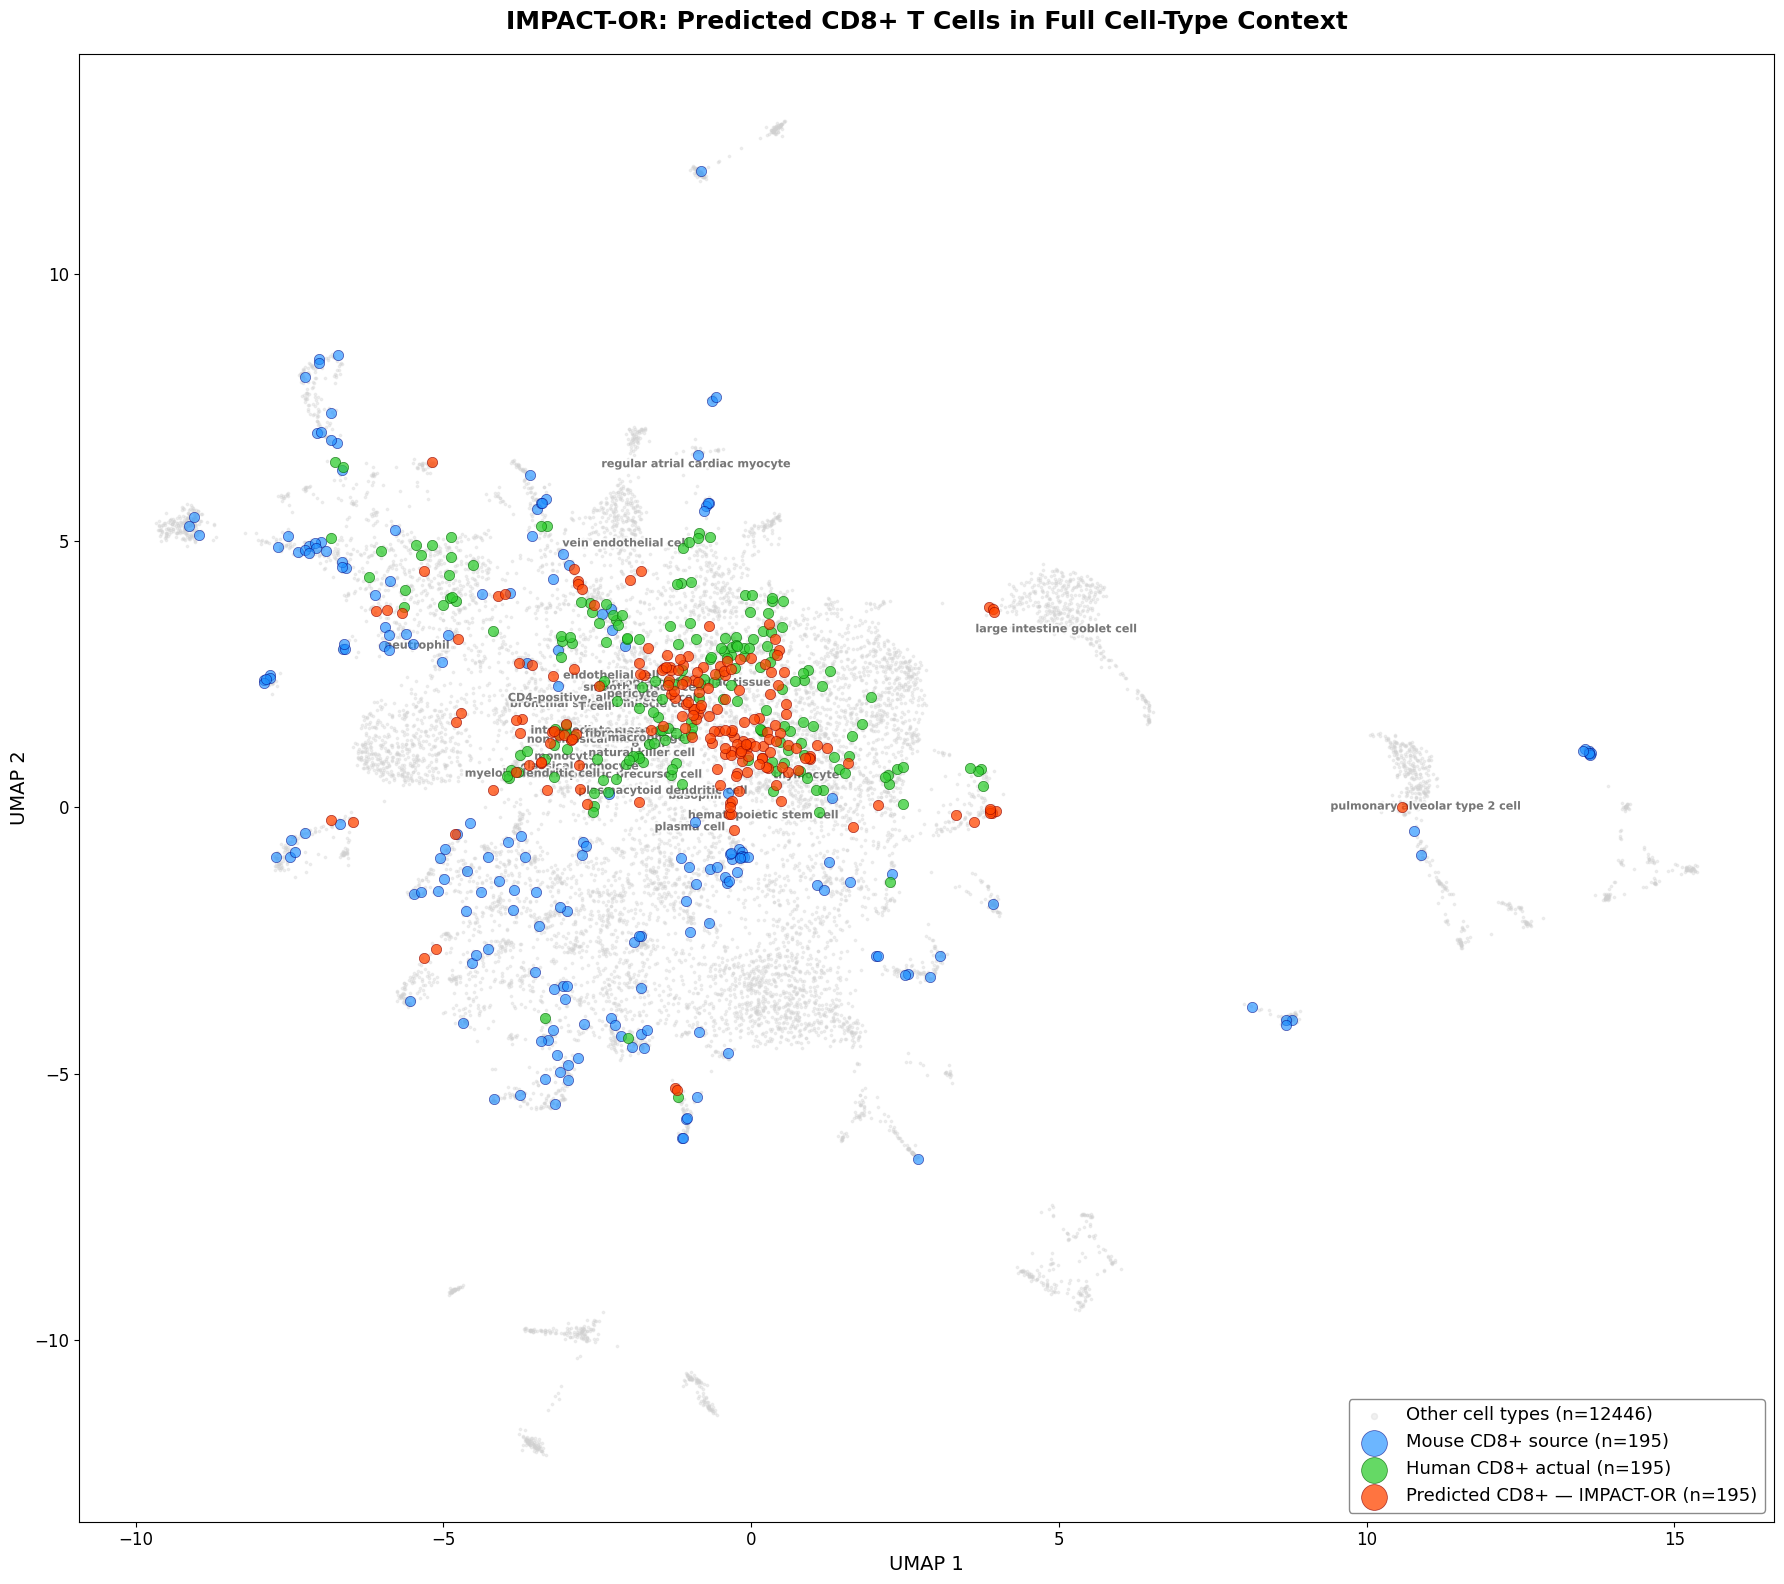

In [11]:
if 'IMPACT-OR' in predictions:
    plot_full_context_umap(ref, predictions['IMPACT-OR'], 'IMPACT-OR')
else:
    print("IMPACT-OR predictions not available — skipping.")

---
### UMAP — CellOT (Conditional OT, condition=cell_type_status)

CellOT uses a swapped framing: condition = cd8 vs non_cd8 (grouping both species together).
It learns cell-type-conditional transport. For OOD evaluation, the held-out human species
within the CD8 condition is predicted from the mouse CD8+ source cells.

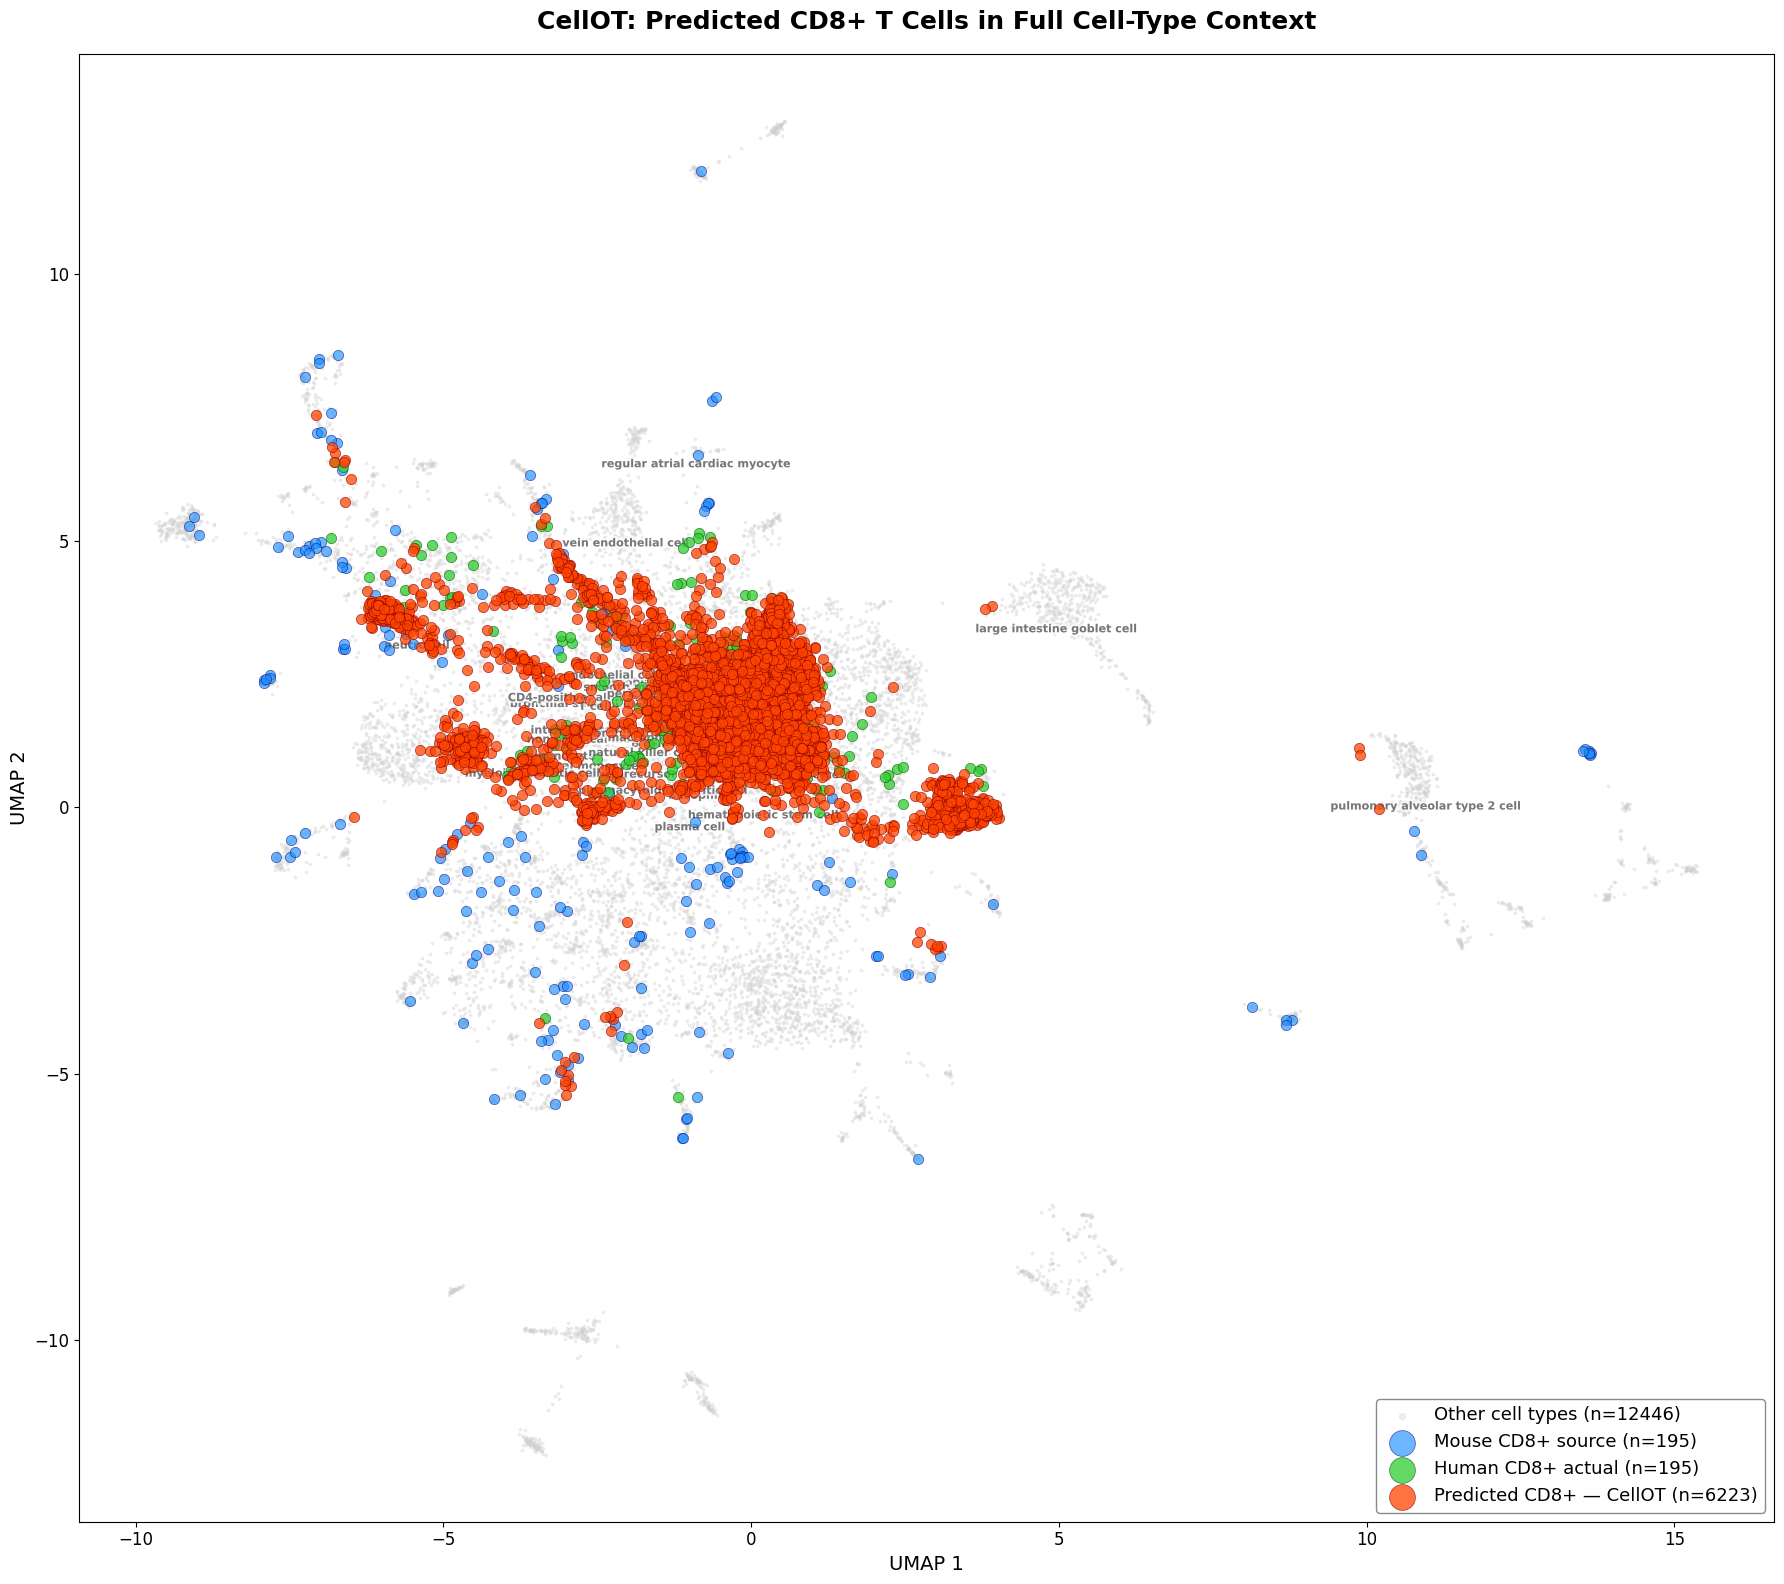

In [12]:
if 'CellOT' in predictions:
    plot_full_context_umap(ref, predictions['CellOT'], 'CellOT')
else:
    print("CellOT predictions not available — skipping.")

In [13]:
if len(predictions) >= 2:
    print("=" * 65)
    print("UMAP Projection Summary: Centroid Distance to Actual Human CD8+")
    print("=" * 65)

    tgt_mask = ((ref.obs[CT_COL].astype(str).str.strip() == HOLDOUT).values &
                (ref.obs['condition'].astype(str).str.strip() == TARGET).values)
    tgt_center = ref.obsm['X_umap'][tgt_mask].mean(axis=0)

    rows = []
    for name, pred in predictions.items():
        pred_center = pred.obsm['X_umap'].mean(axis=0)
        dist = np.linalg.norm(pred_center - tgt_center)
        rows.append({'Model': name, 'Centroid dist (UMAP)': f'{dist:.3f}',
                     'N predicted': pred.obsm['X_umap'].shape[0]})
        print(f"  {name:<12s}: centroid distance = {dist:.3f}")

    print(f"\n  (Lower distance = predicted cells land closer to actual human CD8+ cluster)")

UMAP Projection Summary: Centroid Distance to Actual Human CD8+
  IMPACT-OR   : centroid distance = 0.695
  CellOT      : centroid distance = 0.674

  (Lower distance = predicted cells land closer to actual human CD8+ cluster)
